In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('./letter_recognition/letter-recognition.data') # We load the raw letter recognition dataset from a CSV file into a Pandas DataFrame so that we can easily inspect, manipulate, and preprocess it in subsequent steps.
df # Executing the dataframe variable displays the loaded dataset preview, including its rows, columns, and shape, which is important for verifying that the file was read correctly and for inspecting the feature values.

,T,2,8,3,5,1,8.1,13,0,6,6.1,10,8.2,0.1,8.3,0.2,8.4
0,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
1,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
2,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
3,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10
4,S,4,11,5,8,3,8,8,6,9,5,6,6,0,8,9,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19994,D,2,2,3,3,2,7,7,7,6,6,6,4,2,8,3,7
19995,C,7,10,8,8,4,4,8,6,9,12,9,13,2,9,3,7
19996,T,6,9,6,7,5,6,11,3,7,11,9,5,2,12,2,4
19997,S,2,3,4,2,1,8,7,2,6,10,6,8,1,9,5,8


In [3]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

x=df.iloc[:,1:].values # We extract the input features by selecting all columns except the first one (index 0) and converting them into a raw NumPy array, which is necessary for training our neural network.
y=df.iloc[:,0].values # We extract the target class labels by selecting the very first column (index 0) containing the letters A-Z, representing the ground truth classes for classification.
y = OneHotEncoder(sparse_output=False).fit_transform(y.reshape(-1, 1)) # We apply One-Hot Encoding to convert the categorical character labels (A-Z) into a binary representation matrix, which is required because multi-class classification neural networks predict class probabilities rather than raw string values.

In [4]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) # We split the features and one-hot encoded labels into training (80%) and testing (20%) sets, using a fixed random seed for reproducibility, which allows us to train the model on one portion and evaluate its generalized performance on unseen data.

In [5]:
scaler = StandardScaler() # We instantiate a StandardScaler object to normalize our numerical feature columns by removing the mean and scaling to unit variance.
x_train = scaler.fit_transform(x_train) # We compute the mean and standard deviation on the training features and scale them, which is critical to speed up model convergence and prevent features with larger magnitudes from dominating the learning process.
x_test = scaler.transform(x_test) # We scale the test features using the exact mean and standard deviation learned from the training set to prevent data leakage and ensure standard, consistent input distributions.

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([  # Sequential models are used to build a linear stack of layers where each layer has exactly one input tensor and one output tensor.

    Input(shape=(x_train.shape[1],)),  # The Input layer explicitly defines the input shape based on feature columns. This is important to define the network structure upfront and avoid Keras warnings.
    Dense(128, activation='relu'),  # A fully connected layer with 128 units to learn patterns. The 'relu' activation function introduces non-linearity, enabling the model to learn complex relationships.
    Dropout(0.3),  # Dropout regularization randomly drops 30% of neurons during training, which is important to prevent the model from overfitting to the training data.

    Dense(64, activation='relu'),  # A second fully connected layer with 64 units and 'relu' activation to abstract the learned features into a tighter, more refined set of representations.
    Dropout(0.3),  # Another Dropout layer to further regularize the network and ensure robust, generalized feature learning before final classification.

    Dense(y_train.shape[1], activation='softmax')  # The output layer with 26 neurons (A-Z classes). 'softmax' activation converts raw scores to probabilities that sum to 1.0.
])

In [7]:
model.compile( # We compile the Keras model to configure its training parameters, binding the optimizer, loss function, and performance metrics together before training begins.
    optimizer=Adam(learning_rate=0.001), # We use the Adam optimizer with a learning rate of 0.001 because it dynamically adapts the learning rates of individual weights, resulting in faster and more stable convergence.
    loss='categorical_crossentropy', # We use Categorical Crossentropy as the loss function since it is the standard and mathematically sound loss for multi-class classification where labels are one-hot encoded.
    metrics=['accuracy'] # We specify accuracy as our evaluation metric during training so we can easily monitor the percentage of correctly classified letters across epochs.
)

# Early Stopping
early_stop = EarlyStopping( # We instantiate EarlyStopping to monitor the validation loss during training and automatically stop training if the model performance stops improving, saving valuable compute resources and preventing overfitting.
    monitor='val_loss', # We instruct EarlyStopping to monitor validation set loss as the key metric to determine when the model has reached optimal generalization.
    patience=5, # We set patience to 5, meaning we allow the training to continue for 5 more epochs after a peak in validation loss to confirm that the model has indeed stopped improving.
    restore_best_weights=True # We enable restoring the best weights to ensure that the final model uses the parameters from the epoch with the absolute lowest validation loss, rather than the final overfitted epoch.
)

# Model Summary
model.summary() # We print the model's structural summary to verify the layer order, shapes of intermediate tensors, and the total count of trainable parameters.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,122 (47.35 KB)

 Trainable params: 12,122 (47.35 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit( # We fit the model to begin the supervised training process on the normalized training features and one-hot encoded labels.
    x_train, # We pass the training inputs (features) to the model for learning pattern representations.
    y_train, # We pass the true training labels (target variables) so the optimizer can calculate loss and backpropagate weight corrections.
    epochs=30, # We set the maximum training duration to 30 epochs (passes over the entire training set), allowing the optimizer ample opportunities to fine-tune the weights.
    batch_size=32, # We set a batch size of 32, which processes training samples in small, efficient groups to improve memory efficiency and introduce mini-batch gradient updates.
    validation_split=0.2, # We split 20% of the training set to serve as an independent validation split to monitor validation accuracy and loss during each epoch.
    callbacks=[early_stop] # We supply our early_stop callback to dynamically halt training and rollback weights when validation loss starts worsening.
)

Epoch 1/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3868 - loss: 2.1013 - val_accuracy: 0.6609 - val_loss: 1.1894
Epoch 2/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6022 - loss: 1.2629 - val_accuracy: 0.7406 - val_loss: 0.8970
Epoch 3/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6611 - loss: 1.0651 - val_accuracy: 0.7669 - val_loss: 0.7732
Epoch 4/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7052 - loss: 0.9441 - val_accuracy: 0.7869 - val_loss: 0.6923
Epoch 5/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7291 - loss: 0.8626 - val_accuracy: 0.8056 - val_loss: 0.6292
Epoch 6/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7443 - loss: 0.8192 - val_accuracy: 0.8178 - val_loss: 0.5915
Epoch 7/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7578 - loss: 0.7640 - val_accuracy: 0.8325 - val_loss: 0.5509
Epoch 8/30
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7684 - loss: 0.7274 - val_accuracy: 0.

In [9]:
import numpy as np
from sklearn.metrics import classification_report

# Get predictions
y_pred = model.predict(x_test) # We use the trained model to predict output class probabilities for the unseen test feature set x_test.
y_pred_classes = np.argmax(y_pred, axis=1) # We use argmax to convert the predicted 26-class probability distribution back into a single predicted numerical class index (0-25).
y_true_classes = np.argmax(y_test, axis=1) # We convert the one-hot encoded true test labels back into single target numerical indices (0-25) to compare them directly with the predictions.

# Print classification report
print(classification_report(y_true_classes, y_pred_classes)) # We compute and output a comprehensive classification report containing precision, recall, f1-score, and support metrics for each class, which is vital to understand model performance on individual letters.

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.99      0.93      0.96       144
           1       0.82      0.96      0.88       156
           2       0.93      0.91      0.92       137
           3       0.90      0.92      0.91       148
           4       0.87      0.91      0.89       150
           5       0.92      0.85      0.88       166
           6       0.84      0.89      0.86       161
           7       0.91      0.81      0.86       153
           8       0.95      0.97      0.96       139
           9       0.98      0.91      0.94       141
          10       0.83      0.90      0.86       132
          11       0.99      0.92      0.95       170
          12       0.97      0.94      0.96       158
          13       0.95      0.87      0.91       164
          14       0.88      0.95      0.91       153
          15       0.92      0.89      0.90       159
          16       0.95      0.96      0

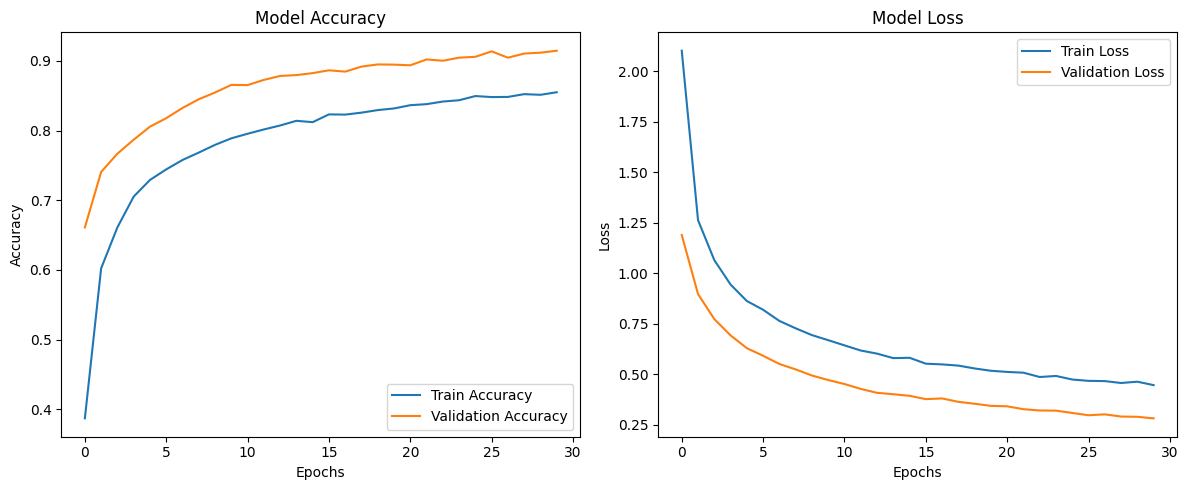

In [10]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(12, 5)) # We initialize a matplotlib figure window of width 12 and height 5 inches to neatly arrange multiple validation plots side-by-side.

# Accuracy plot
plt.subplot(1, 2, 1) # We set up the first subplot panel out of a 1-row, 2-column grid to visualize the progression of model classification accuracy.
plt.plot(history.history['accuracy'], label='Train Accuracy') # We plot training set accuracy values across all completed epochs to visualize how well the network fits the training data.
plt.plot(history.history['val_accuracy'], label='Validation Accuracy') # We plot validation set accuracy to track how well the model generalizes over time and verify that training accuracy doesn't diverge excessively.
plt.xlabel('Epochs') # We label the horizontal axis as Epochs to represent time steps of the training process.
plt.ylabel('Accuracy') # We label the vertical axis as Accuracy to show the classification success rate.
plt.title('Model Accuracy') # We set the title of the left plot to clearly indicate that it displays the training and validation accuracy curves.
plt.legend() # We display the legend to distinguish the training accuracy line from the validation accuracy line.

# Loss plot
plt.subplot(1, 2, 2) # We set up the second subplot panel in the grid to visualize the change in categorical crossentropy loss across training.
plt.plot(history.history['loss'], label='Train Loss') # We plot the training loss curve, which should ideally steadily decline as the optimization algorithm minimizes prediction errors.
plt.plot(history.history['val_loss'], label='Validation Loss') # We plot the validation loss curve to verify that the model is learning generalized rules; a rising validation loss curve is a classic sign of overfitting.
plt.xlabel('Epochs') # We label the horizontal axis of the loss plot as Epochs for consistent time tracking.
plt.ylabel('Loss') # We label the vertical axis as Loss to show the magnitude of prediction error.
plt.title('Model Loss') # We set the title of the right plot to show it presents the training and validation loss curves.
plt.legend() # We display the legend for the right subplot to easily identify the train and validation loss curves.

plt.tight_layout() # We adjust the subplot layouts automatically to prevent axis labels or plot titles from overlapping, maintaining a highly readable and professional design.
plt.show() # We display the fully constructed figures in the output cell to complete the plotting step.

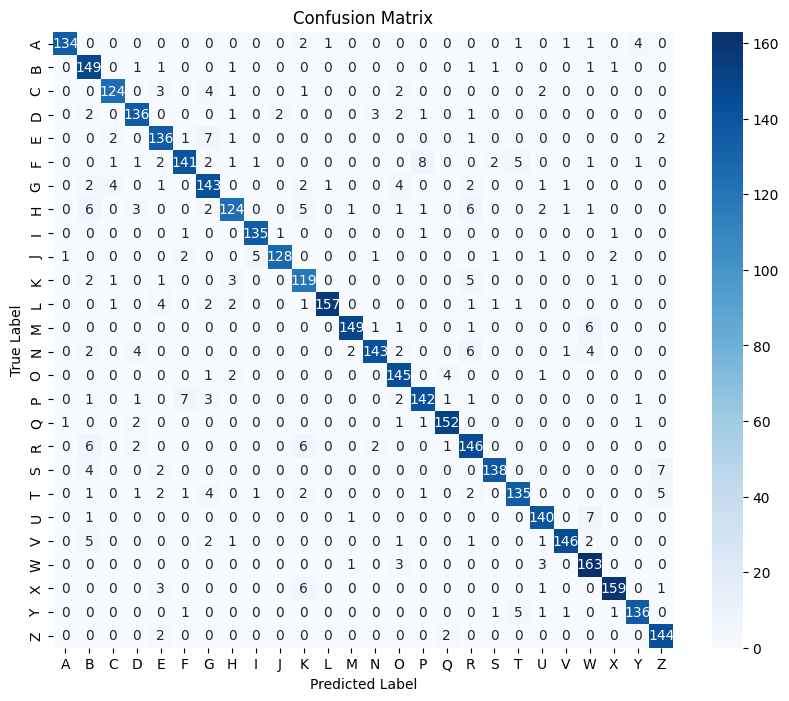

In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes) # We compute a 26x26 confusion matrix comparing true letter classes with predicted letter classes to systematically locate exactly which letters are being misclassified.

# Plot
plt.figure(figsize=(10, 8)) # We define a figure of size 10x8 inches to ensure the 26x26 confusion matrix is plotted at a high enough resolution to read cell values clearly.

label_encoder = LabelEncoder() # We instantiate a LabelEncoder object to dynamically map our one-hot indices back to their original alphabetical letters A-Z.
label_encoder.fit(df['T']) # We fit the LabelEncoder on the first column of our original DataFrame to capture the alphabet labels in their correct order.

sns.heatmap( # We use Seaborn's heatmap utility to draw a beautiful, color-coded grid representing the frequency of correct and incorrect predictions.
    cm, # We pass the computed 26x26 confusion matrix to be mapped visually.
    annot=True, # We enable numerical annotations in each grid cell to print the exact count of predictions directly on the heatmap.
    fmt="d", # We format the annotations as decimal integers rather than floating point numbers to ensure clean representation of prediction counts.
    cmap="Blues", # We select the 'Blues' color palette to represent higher prediction densities with darker blue colors, making classification patterns instantly readable.
    xticklabels=label_encoder.classes_, # We label the horizontal columns with original class letters A-Z to easily identify predicted classes.
    yticklabels=label_encoder.classes_ # We label the vertical rows with original class letters A-Z to easily identify actual class letters.
)


plt.xlabel('Predicted Label') # We label the x-axis to indicate that horizontal columns represent the class predicted by the neural network.
plt.ylabel('True Label') # We label the y-axis to indicate that vertical rows represent the true class of each sample.
plt.title('Confusion Matrix') # We title the heatmap to clearly state the type of evaluation plot being shown.

plt.show() # We draw the final, annotated confusion matrix heatmap on the output screen.